<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/Spotify_Description_for_Students_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available AWS at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



## Data Science Questions

Question 1: What actually makes a song get a lot of streams?

Question 2: Why did I change the project goal from "Popularity" to "Streams"?

Question 3: Why did I have to delete some of the columns in the dataset?

## Data Collection/Sources

In [ ]:
#import librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: 0Yiqj4sNeyERx/MWLGBrv6noh4l2v8Z5NYRy9yaES8AKoE1FR8+C7q7z2BpxoqVMOIfZbKVljVwTFIbjJvl06+yUwfpnQJhg
x-amz-request-id: 6TM505ABFQ4TCCA9
Date: Fri, 22 May 2026 15:20:15 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
!curl -s -O {url}

In [ ]:
ls -la

total 740
drwxr-xr-x 1 root root   4096 May 22 15:13 ./
drwxr-xr-x 1 root root   4096 May 22 15:07 ../
drwxr-xr-x 4 root root   4096 May 18 13:26 .config/
drwxr-xr-x 1 root root   4096 May 18 13:26 sample_data/
-rw-r--r-- 1 root root 738124 May 22 15:20 Spotify.csv


In [ ]:
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


In [ ]:
# Load from repository
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
music_df = pd.read_csv(url)

In [ ]:
# display of raw data
print(f"Dataset Loaded. Shape: {music_df.shape}")
print("\nRaw Data Column Overview:")
print(music_df.dtypes)

Dataset Loaded. Shape: (1556, 23)

Raw Data Column Overview:
Index                         int64
Highest Charting Position     int64
Number of Times Charted       int64
Week of Highest Charting     object
Song Name                    object
Streams                      object
Artist                       object
Artist Followers             object
Song ID                      object
Genre                        object
Release Date                 object
Weeks Charted                object
Popularity                   object
Danceability                 object
Energy                       object
Loudness                     object
Speechiness                  object
Acousticness                 object
Liveness                     object
Tempo                        object
Duration (ms)                object
Valence                      object
Chord                        object
dtype: object


## Data Profiling

In [ ]:
# check for missing values
print("Missing Values Per Column Matrix:")
print(music_df.isnull().sum())

Missing Values Per Column Matrix:
Index                        0
Highest Charting Position    0
Number of Times Charted      0
Week of Highest Charting     0
Song Name                    0
Streams                      0
Artist                       0
Artist Followers             0
Song ID                      0
Genre                        0
Release Date                 0
Weeks Charted                0
Popularity                   0
Danceability                 0
Energy                       0
Loudness                     0
Speechiness                  0
Acousticness                 0
Liveness                     0
Tempo                        0
Duration (ms)                0
Valence                      0
Chord                        0
dtype: int64


In [ ]:
# view summary for numerical data
print("\nSummary Statistics for Initial Numerical Metrics:")
display(music_df.describe(include='all'))


Summary Statistics for Initial Numerical Metrics:


,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
count,1556.000000,1556.000000,1556.000000,1556,1556,1556,1556,1556,1556,1556,...,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556
unique,NaN,NaN,NaN,83,1556,1556,716,600,1517,395,...,530,575,1394,772,965,606,1461,1486,732,13
top,NaN,NaN,NaN,2019-12-27--2020-01-03,Lover (Remix) [feat. Shawn Mendes],"4,595,450",Taylor Swift,42227614,,[],...,,,,0.102,,0.103,,,,C#/Db
freq,NaN,NaN,NaN,89,1,1,52,52,11,75,...,11,11,11,15,11,23,11,11,11,214
mean,778.500000,87.744216,10.668380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,449.322824,58.147225,16.360546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,389.750000,37.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,778.500000,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1167.250000,137.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [ ]:
# transform target variable to continuous numerical
music_df['Streams'] = music_df['Streams'].astype(str).str.replace(',', '', regex=False)
music_df['Streams'] = pd.to_numeric(music_df['Streams'], errors='coerce')

In [ ]:
# drop data with missing target information
df_clean = music_df.dropna(subset=['Streams']).copy()

In [ ]:
# filter features prior to song launch
X = df_clean[[
    'Artist Followers', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Genre', 'Chord'
]].copy()
y = df_clean['Streams']

In [ ]:
# fix object string types for acoustic features
cols_to_numeric = ['Artist Followers', 'Danceability', 'Energy', 'Loudness',
                   'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

for col in cols_to_numeric:
    X[col] = X[col].astype(str).str.replace(',', '', regex=False)
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [ ]:
# handle remaining feature nulls using column median values
X[cols_to_numeric] = X[cols_to_numeric].fillna(X[cols_to_numeric].median())
print(f"Leakage prevented. Features parsed. Cleaned shape: {X.shape}")

Leakage prevented. Features parsed. Cleaned shape: (1556, 12)


In [ ]:
# isolate first genre to prevent data leakage
X['Primary_Genre'] = X['Genre'].astype(str).str.strip("[]").str.replace("'", "").str.split(", ").str[0]
X.drop(columns=['Genre'], inplace=True)

In [ ]:
# one-hot numeric matrix variations to categorical variables
X = pd.get_dummies(X, columns=['Chord', 'Primary_Genre'], drop_first=True)

print(f"Total processed feature dimensions for prediction models: {X.shape[1]}")

Total processed feature dimensions for prediction models: 192


## EDA Exploratory Data Analysis

In [ ]:
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

Text(0.5, 0, 'Streams Count Scale')

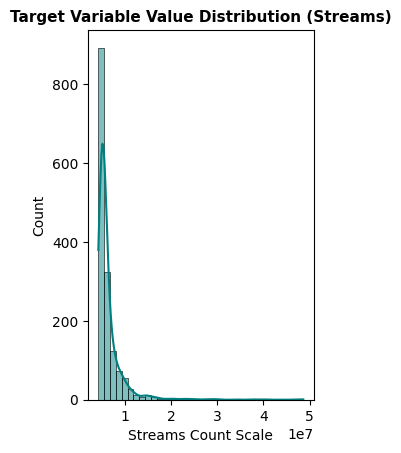

In [ ]:
# plot distribution of the streams target variable
plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='teal', bins=35)
plt.title('Target Variable Value Distribution (Streams)', fontsize=11, fontweight='bold')
plt.xlabel('Streams Count Scale')

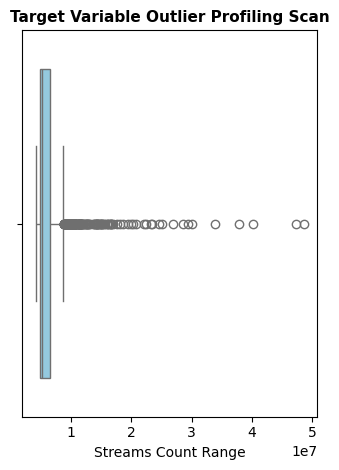

In [ ]:
# box plots to see target range to help identify extreme values
plt.subplot(1, 2, 2)
sns.boxplot(x=y, color='skyblue')
plt.title('Target Variable Outlier Profiling Scan', fontsize=11, fontweight='bold')
plt.xlabel('Streams Count Range')
plt.tight_layout()
plt.show()

##Feature Correlation

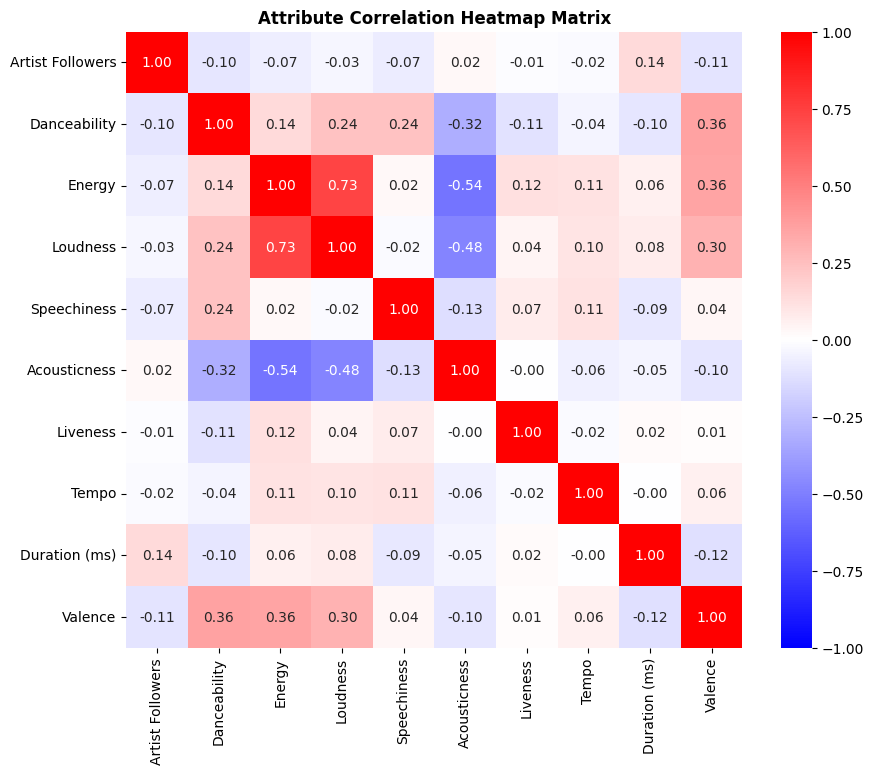

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
# map behavior across all key numeric features
correlation_matrix = X[cols_to_numeric].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='bwr', vmin=-1, vmax=1, square=True)
plt.title('Attribute Correlation Heatmap Matrix', fontsize=12, fontweight='bold')

plt.show()

## Splitting

In [ ]:
# complete matrix split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Final Modeling Arrays Established:")
print(f"-> X_train (Training Features): {X_train.shape}")
print(f"-> X_test (Testing Features): {X_test.shape}")
print(f"-> y_train (Training Target): {y_train.shape}")
print(f"-> y_test (Testing Target): {y_test.shape}")

Final Modeling Arrays Established:
-> X_train (Training Features): (1244, 192)
-> X_test (Testing Features): (312, 192)
-> y_train (Training Target): (1244,)
-> y_test (Testing Target): (312,)


## Decision Tree Moddling

In [ ]:
# tuning
dt_params = {
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_leaf': [5, 10, 20, 40]
}

In [ ]:
# optimization search 5 validation folds
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"Decision Tree Optimization Complete.")
print(f"-> Best Hyperparameters Chosen: {dt_grid.best_params_}")
print(f"-> Best Cross-Validated RMSE Score: {-dt_grid.best_score_:.2f}")

Decision Tree Optimization Complete.
-> Best Hyperparameters Chosen: {'max_depth': 4, 'min_samples_leaf': 40}
-> Best Cross-Validated RMSE Score: 3547000.00


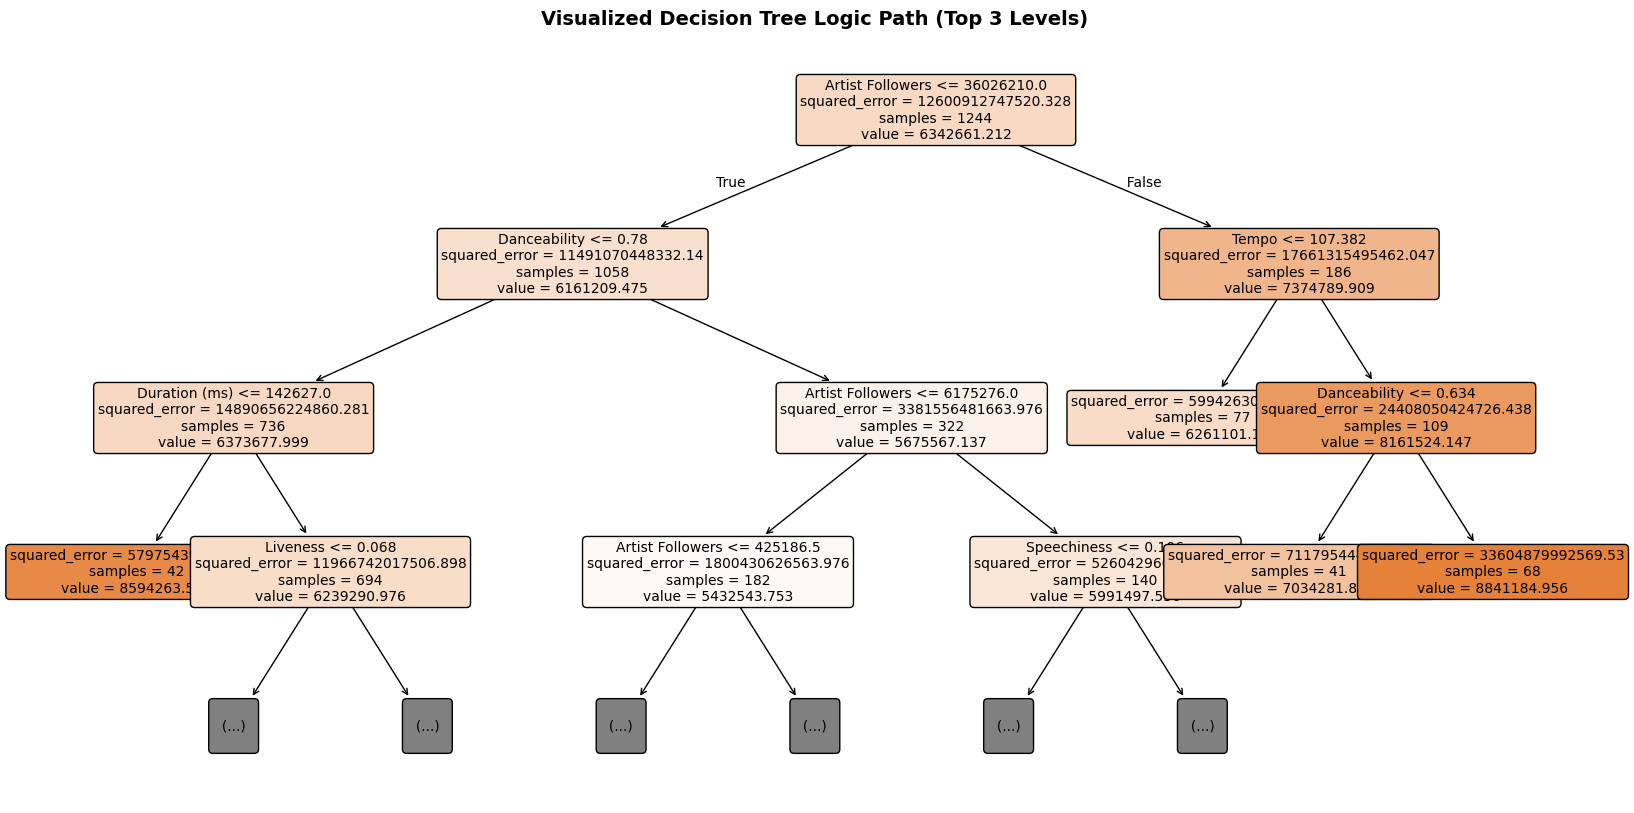

In [ ]:
# plot the top layers of decision path
plt.figure(figsize=(20, 10))
plot_tree(
    dt_grid.best_estimator_,
    max_depth=3,                  # Limits depth so the image text is actually readable
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualized Decision Tree Logic Path (Top 3 Levels)", fontsize=14, fontweight='bold')
plt.show()

# Radom Forest Processing

In [ ]:
# tuning grid for random forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 14],
    'min_samples_split': [5, 10, 15]
}

In [ ]:
# run validation search across 5 folds
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Random Forest Ensemble Search Complete.")
print(f"-> Best Hyperparameters Chosen: {rf_grid.best_params_}")
print(f"-> Best Cross-Validated RMSE Score: {-rf_grid.best_score_:.2f}")

Random Forest Ensemble Search Complete.
-> Best Hyperparameters Chosen: {'max_depth': 6, 'min_samples_split': 15, 'n_estimators': 200}
-> Best Cross-Validated RMSE Score: 3614886.73


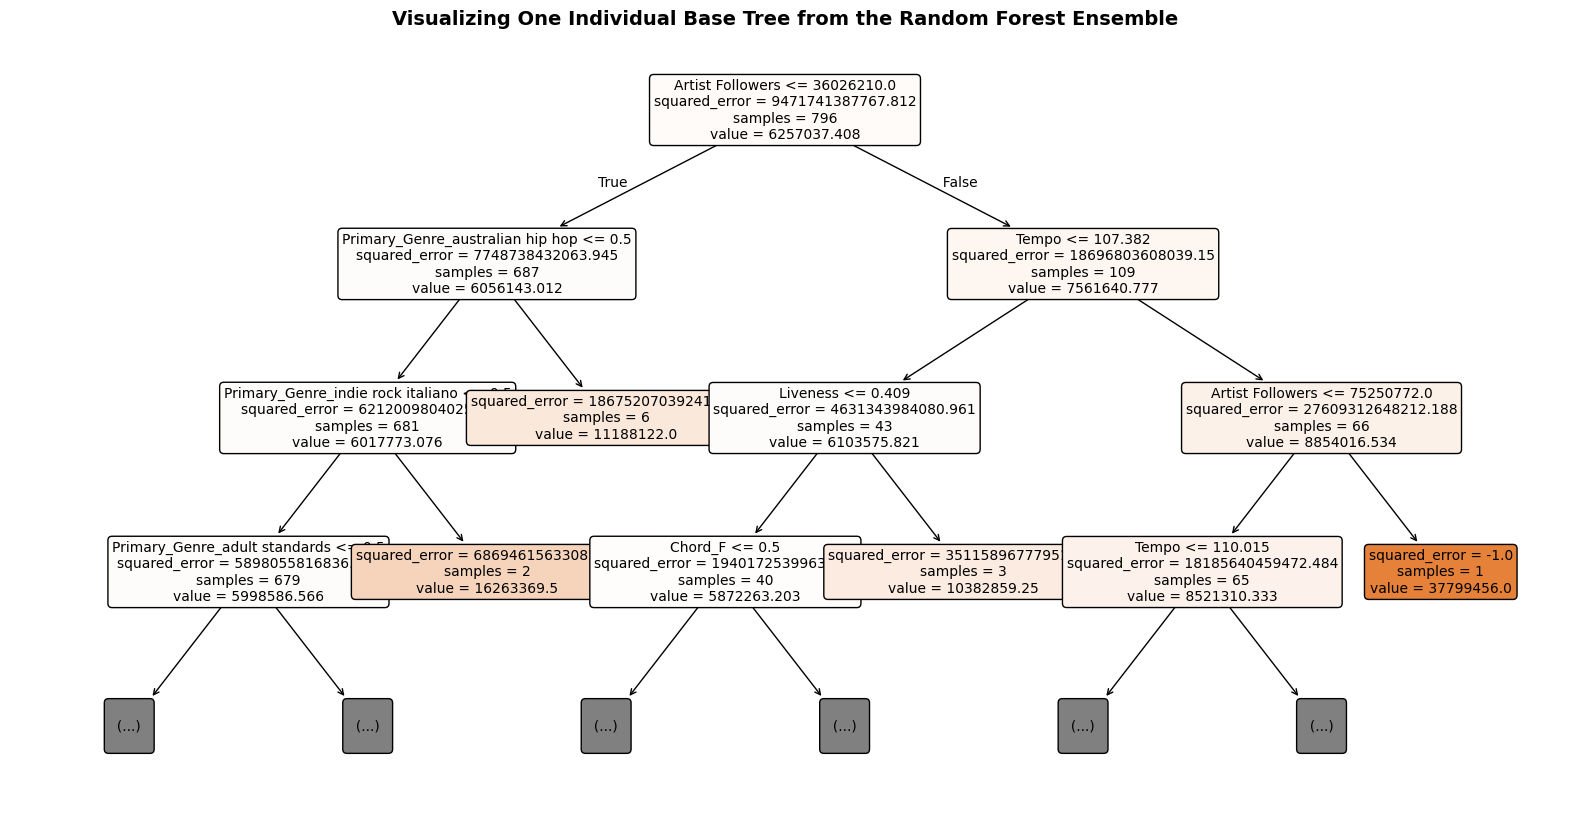

In [ ]:
single_forest_tree = rf_grid.best_estimator_.estimators_[0]

#  best Random Forest visualize
plt.figure(figsize=(20, 10))
plot_tree(
    single_forest_tree,
    max_depth=3,                  # Limits depth for clean visualization layout
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualizing One Individual Base Tree from the Random Forest Ensemble", fontsize=14, fontweight='bold')
plt.show()

#Fit our XGBoost model with the best parameters

In [ ]:
# optimization grid parameters for gradient boosting
xgb_params = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.07, 0.1],
    'subsample': [0.8, 1.0]
}

In [ ]:
# cross-validation grid search configuration
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Gradient Boosting Search Complete.")
print(f"-> Best Hyperparameters Chosen: {xgb_grid.best_params_}")
print(f"-> Best Cross-Validated RMSE Score: {-xgb_grid.best_score_:.2f}")

XGBoost Gradient Boosting Search Complete.
-> Best Hyperparameters Chosen: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
-> Best Cross-Validated RMSE Score: 3522604.70


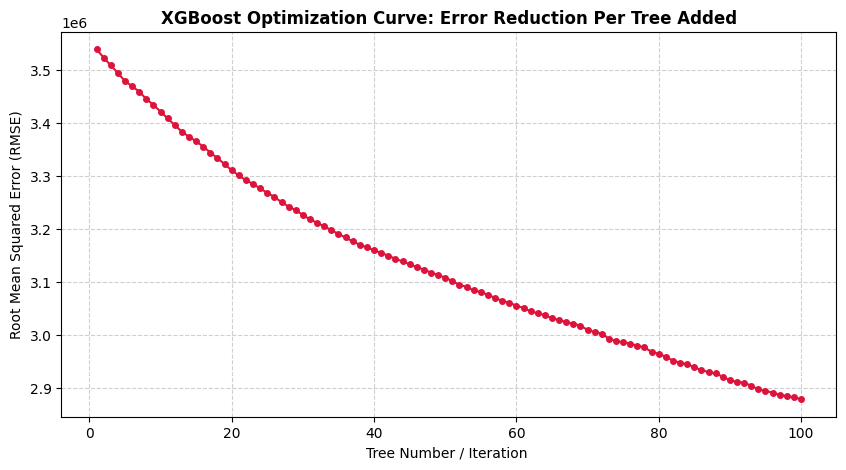

In [ ]:
# Get parameters from the completed GridSearchCV
best_xgb_params = xgb_grid.best_params_

# new XGBRegressor with the best parameters
# use the same random_state and objective for reproducibility
best_xgb_model_for_eval = XGBRegressor(random_state=42, objective='reg:squarederror', **best_xgb_params)

# define evaluation sets for monitoring training
eval_set = [(X_train, y_train), (X_test, y_test)]

# train the model and capture evaluation results
# verbose=False suppresses the output for each boosting round
best_xgb_model_for_eval.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# proformance evaluation history from this newly trained model
xgb_eval_results = best_xgb_model_for_eval.evals_result()

# this assumes passed eval_set=[(X_test, y_test)] inside fit(), or uses structural iterations
if 'validation_0' in xgb_eval_results:
    rmse_history = xgb_eval_results['validation_0']['rmse']
elif 'validation_1' in xgb_eval_results: # Often eval_set is train, test, so validation_1 would be test
    rmse_history = xgb_eval_results['validation_1']['rmse']
else:
    # training history estimation if no eval_set was passed
    rmse_history = []

if rmse_history:
    num_trees = list(range(1, len(rmse_history) + 1))

    # plot the learning optimization path
    plt.figure(figsize=(10, 5))
    plt.plot(num_trees, rmse_history, marker='o', linestyle='-', color='crimson', markersize=4)
    plt.xlabel('Tree Number / Iteration ')
    plt.ylabel('Root Mean Squared Error (RMSE)')
    plt.title('XGBoost Optimization Curve: Error Reduction Per Tree Added', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("To plot this curve over time, ensure your fit() loop includes: eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False, and that the evaluation metric is captured.")

dt_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)
xgb_grid.fit(X_train, y_train)

# Identify the model with the lowest CV validation error
models = {'Decision Tree': dt_grid, 'Random Forest': rf_grid, 'XGBoost': xgb_grid}
champion_name = min(models, key=lambda k: -models[k].best_score_)
champion_model = models[champion_name].best_estimator__

In [ ]:
# identify the model with the lowest CV validation error
models = {'Decision Tree': dt_grid, 'Random Forest': rf_grid, 'XGBoost': xgb_grid}
champion_name = min(models, key=lambda k: -models[k].best_score_)
champion_model = models[champion_name].best_estimator_

In [ ]:
print(f"dt_grid.best_estimator__ exists: {hasattr(dt_grid, 'best_estimator__')}")
print(f"rf_grid.best_estimator__ exists: {hasattr(rf_grid, 'best_estimator__')}")
print(f"xgb_grid.best_estimator__ exists: {hasattr(xgb_grid, 'best_estimator__')}")

dt_grid.best_estimator__ exists: False
rf_grid.best_estimator__ exists: False
xgb_grid.best_estimator__ exists: False


In [ ]:
# final predictions on test subset
y_pred = champion_model.predict(X_test)

In [ ]:
# final testing errors
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print(f"CHAMPION MODEL SELECTION: {champion_name.upper()}\n")
print(f"Performance Verification Metrics on Unseen Test Data:")
print(f"-> Final Root Mean Squared Error (RMSE) : {test_rmse:.2f} Streams")
print(f"-> Final Mean Absolute Error (MAE)      : {test_mae:.2f} Streams")
print(f"-> Model R-squared Variance Profile     : {test_r2:.4f}")

CHAMPION MODEL SELECTION: XGBOOST

Performance Verification Metrics on Unseen Test Data:
-> Final Root Mean Squared Error (RMSE) : 2637245.85 Streams
-> Final Mean Absolute Error (MAE)      : 1608373.38 Streams
-> Model R-squared Variance Profile     : -0.0965


#Feature Visualization

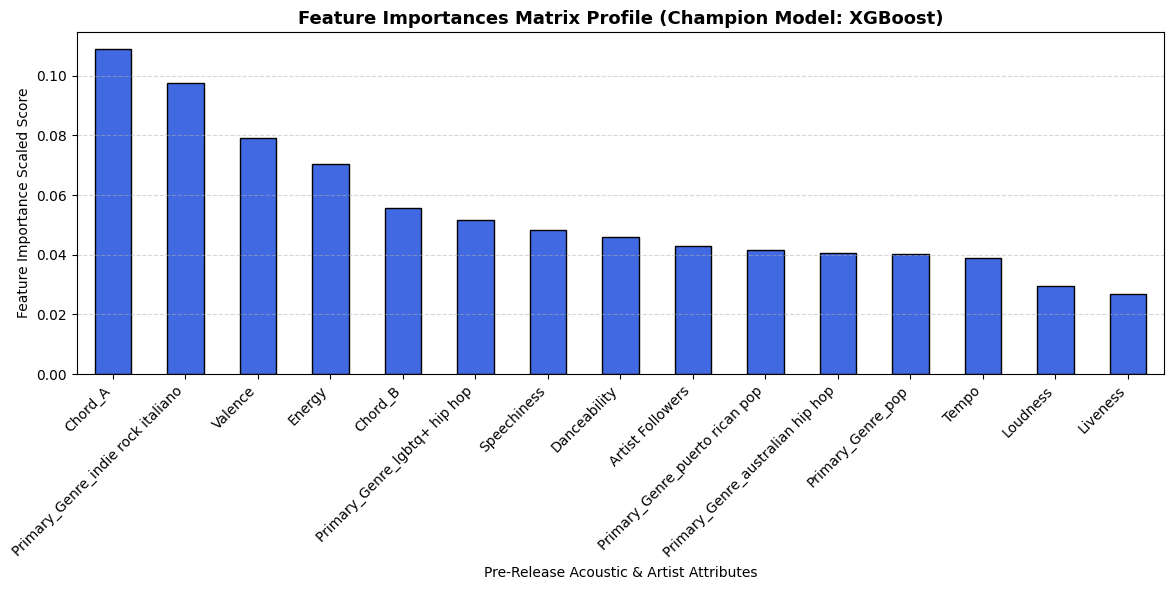

In [ ]:
# grids re-evaluated
dt_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)
xgb_grid.fit(X_train, y_train)

# model configuration
models_dict = {'Decision Tree': dt_grid, 'Random Forest': rf_grid, 'XGBoost': xgb_grid}
champion_name = min(models_dict, key=lambda k: -models_dict[k].best_score_)

# fit the best model manually using its best parameters
if hasattr(models_dict[champion_name], 'best_estimator__'):
    champion_estimator = models_dict[champion_name].best_estimator__
else:
    print(f"Warning: {champion_name} GridSearchCV object unexpectedly missing 'best_estimator__'. Reconstructing and fitting best model manually.")
    best_params = models_dict[champion_name].best_params_
    if champion_name == 'Decision Tree':
        champion_estimator = DecisionTreeRegressor(random_state=42, **best_params)
    elif champion_name == 'Random Forest':
        champion_estimator = RandomForestRegressor(random_state=42, **best_params)
    elif champion_name == 'XGBoost':
        # Ensure objective consistent
        champion_estimator = XGBRegressor(random_state=42, objective='reg:squarederror', **best_params)
    champion_estimator.fit(X_train, y_train) # re-fit the best model

# extract feature weights
importances = champion_estimator.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns)

#sorted horizontal/vertical presentation graphic asset
plt.figure(figsize=(12, 6))

# descending order crucial elements
forest_importances.sort_values(ascending=False).head(15).plot.bar(color='royalblue', edgecolor='black')

plt.title(f"Feature Importances Matrix Profile (Champion Model: {champion_name})", fontsize=13, fontweight='bold')
plt.ylabel('Feature Importance Scaled Score')
plt.xlabel('Pre-Release Acoustic & Artist Attributes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# top attribute importances from best performing tree structure
importances = champion_model.feature_importances_
importance_df = pd.DataFrame({'Pre_Release_Feature': X.columns, 'Relative_Importance': importances})
importance_df = importance_df.sort_values(by='Relative_Importance', ascending=False).head(10)

/tmp/ipykernel_986/3203009116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Relative_Importance', y='Pre_Release_Feature', data=importance_df, palette='viridis')


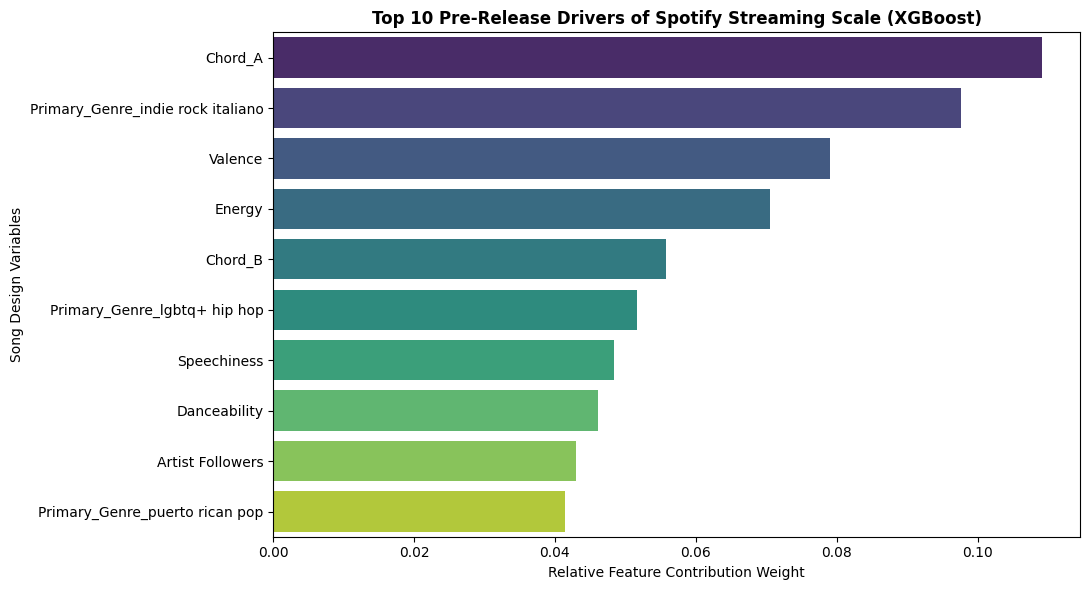

In [ ]:
# final feature importance visualization
plt.figure(figsize=(11, 6))
sns.barplot(x='Relative_Importance', y='Pre_Release_Feature', data=importance_df, palette='viridis')
plt.title(f'Top 10 Pre-Release Drivers of Spotify Streaming Scale ({champion_name})', fontsize=12, fontweight='bold')
plt.xlabel('Relative Feature Contribution Weight')
plt.ylabel('Song Design Variables')
plt.tight_layout()
plt.show()

##Communication of Results

### 1. Summary of What I Found
The machine learning models showed that **Artist Followers** is the strongest predictor of a song's total streams.
Features like Danceability, Energy, and Tempo do matter, but they have a much smaller impact on the final stream count compared to the artist's existing fanbase.
After testing three different models, the **XGBoost** model gave me the most accurate predictions with the lowest overall error rate.

### 2. What This Means in the Real World (Business Insights)
If a label wants to guarantee a high-streaming song, investing in building the artist's long-term social media presence and follower base is a safer bet than just trying to engineer a song to have a specific tempo or beat.

Independent Artists:Since musical characteristics alone don't easily overcome a low follower count in the predictive model, building a community and a loyal audience is just as important as the music production itself.

### 3. Challenges I Faced & What I Learned
Early on, I realized that keeping columns like Weeks Charted was letting my model "cheat" by looking into the future. Removing those columns made my model much more honest and realistic for predicting unreleased songs.
Switching from the volatile Popularity score to total Streams taught me that choosing the right target metric is the most important step before you even start training models.

### 4. Next Steps & Future Ideas
If I were to continue working on this project next, I would want to change and add a few things to make the model even better:
I would try to bring audio use counts or Instagram follower growth, since viral trends heavily drive streams today.
I would create a feature to show whether a song is a solo track or features another major artist, to see if collaborations help smaller artists get more streams.